# Ames Housing Step-by-step - Exercise 5 and 6 - Solution

Pieter Overdevest  
2025-01-23

For suggestions/questions regarding this notebook, please contact
[Pieter Overdevest](https://www.linkedin.com/in/pieteroverdevest/)
(pieter@innovatewithdata.nl).

### How to work with this Jupyter Notebook yourself?

- Get a copy of the repository ('repo') [introduction-track-for-participants](https://github.com/EAISI/introduction-track-for-participants) from EAISI's GitHub site. This can be done by either cloning the repo or simply downloading the zip-file. Both options are explained in this Youtube video by [Coderama](https://www.youtube.com/watch?v=EhxPBMQFCaI).

- Copy the folder 'pieterov\\' located in the folder 'discover-project-examples\\' to your own project folder. I suggest you leave these files as a source to the original files. Create a copy of any notebooks you want to work with and place them in your 'Code' folder. This way it is clear what files you work with and you can keep the original files for reference.

### Import packages

In [1]:
# Third party packages.
import os

import pandas as pd             # Data handling
import polars as pl             # Data handling ('Blazingly fast DataFrames'), alternative to Pandas.
import polars.selectors as cs   # Select columns of particular type.
import numpy as np              # Numeric calculations
import pickle                   # Save and load data
import altair as alt            # Visualize data
import seaborn as sns           # Visualize data
import matplotlib.pyplot as plt # Visualize data

from icecream import ic         # Print variables.

from sklearn.model_selection    import train_test_split     # Split data
from sklearn.preprocessing      import StandardScaler       # Scale data
from sklearn.linear_model       import LinearRegression     # Linear regression
from sklearn.linear_model       import LassoCV              # Lasso regression
from sklearn.preprocessing      import OneHotEncoder        # One hot encoding
from sklearn.neighbors          import KNeighborsRegressor  # KNN regression
from sklearn.model_selection    import GridSearchCV         # Grid search

# Pieter's utils package.
from utils_pieter import f_train_test_split, f_evaluate_results

Done!


### Load objects from earlier exercises

In [2]:
with open('data/dc-ames-housing-pieter-exercise-4.pkl', 'rb') as pickle_file:
    dc_exercise_4 = pickle.load(pickle_file)

df_pd_reduced    = dc_exercise_4['df_pd_reduced']
df_pl_reduced    = dc_exercise_4['df_pl_reduced']
df_pd_scoped     = dc_exercise_4['df_pd_scoped']
df_pl_scoped     = dc_exercise_4['df_pl_scoped']
ps_y_reduced_log = dc_exercise_4['ps_y_reduced_log']
ps_y_scoped_log  = dc_exercise_4['ps_y_scoped_log']
l_df_str_names   = dc_exercise_4['l_df_str_names']
l_df_num_names   = dc_exercise_4['l_df_num_names']
l_df_X_names     = dc_exercise_4['l_df_X_names']
df_pd_corr_table = dc_exercise_4['df_pd_corr_table']
df_pl_corr_table = dc_exercise_4['df_pl_corr_table']

### Notebook settings

In [3]:
# Pandas.
pd.set_option("display.max_rows", None)         # How many rows to display when printing a DataFrame? None shows all rows.
pd.set_option("display.max_columns", None)      # How many columns to display when printing a DataFrame? None shows all columns.
pd.set_option("display.max_info_columns", 100)  # How many rows to display for .info()?
pd.set_option("display.max_info_rows", 1000000) # How many columns to display for .info()?
pd.set_option("display.precision", 4)           # How many decimals to show when printing a DataFrame?

# Polars.
pl.Config.set_tbl_rows(100)         # How many rows to display when printing a DataFrame?
pl.Config.set_tbl_cols(1_000_000)   # How many columns to display when printing a DataFrame? 1 million is to effectively show all columns.

os.environ["POLARS_MAX_THREADS"] = "4"  # How many threads/logical processors to use.

## Exercise 5 - Estimate a Linear Regression, a LASSO and a kNN model

The models that we develop in this section originate from the [SciKit-Learn](https://scikit-learn.org/stable/) library.

We start with the development of a linear regression model, see references, [sklearn.linear_model.LinearRegression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html) and ['Linear Regression in Python' by Dannar Mawardi](https://towardsdatascience.com/linear-regression-in-python-9a1f5f000606).

#### a. Estimate a Linear Regression model, see scikit-learn's [LinearRegression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html)

##### a1. Recap our objects and define a few more

Previously, we defined data frames, `df_scoped_pd_num` and `df_pd_scoped_str`, and the lists holding their respective variable names, `l_df_num_names` and `l_df_str_names`. We also defined the list `l_df_X_names` as a subset of `l_df_num_names`, excluding `SalePrice` and `SalePrice_log`. Below, we define data frame `df_pd_X` containing the data of the variable in `l_df_X_names`. 

As in the previous exercises, I share solutions using both Pandas and Polars data frames. Feel free to replace '\_pd_' by '\_pl_'. I will let you know in case you need to do something extra.

To confirm we did our book keeping right, we confirm that: (1) `l_df_X_names` is two items shorter than `l_df_num_names`, namely `SalePrice` and `SalePrice_log`, and (2) `l_df_num_names` and `l_df_str_names` make up all variables in the reduced and scoped data.

In [4]:
print(f"Length of l_df_X_names:          {len(l_df_X_names)}")
print(f"Length of l_df_num_names:        {len(l_df_num_names)}")
print(f"Length of l_df_str_names:        {len(l_df_str_names)}")
print(f"Number of columns in df_reduced: {len(df_pd_reduced.columns)}")
print(f"Number of columns in df_scope:   {len(df_pd_scoped.columns)}")

Length of l_df_X_names:          38
Length of l_df_num_names:        40
Length of l_df_str_names:        44
Number of columns in df_reduced: 84
Number of columns in df_scope:   84


Add/remove the hash tag at the start of the line depending on your scenario of interest. Note, `df_pd_reduced` contains all observations that we reduced in memory size by converting the string type data to the categorical type and downcasted the numerical data to their smallest container (integer or float), and in `df_pd_scoped` we dropped the houses that have `Gr Liv Area` > 4000 sq ft.

In [5]:
# All data.
#df_data, ps_y_data_log = df_pd_reduced.copy(), ps_y_reduced_log.copy()
#df_data, ps_y_data_log = df_pl_reduced.clone(), ps_y_reduced_log.copy()

# Removed houses that have `Gr Liv Area` > 4000 sq ft.
df_data, ps_y_data_log = df_pd_scoped.copy(), ps_y_scoped_log.copy()
#df_data, ps_y_data_log = df_pl_scoped.clone(), ps_y_scoped_log.copy()

We define `df_X` as the data frame holding all numerical variables - except `SalePrice` and `SalePrice_log` - that we will use to predict the outcome variable (`SalePrice_log`). 

You may wonder, how about the categorical variables, will we use them as predictors? Good question, the short answer is yes, more to come later.



In [6]:
df_X = df_data[l_df_X_names]

We start simple and build a linear model considering the numerical variables with the highest correlation with `SalePrice_log`, the outcome variable (Y) that we want to predict. We consider this our baseline model, to compare later models to.

In [7]:
l_df_X_names_subset = ['Overall Qual']
#l_df_X_names_subset = ['Overall Qual', 'Gr Liv Area']
#l_df_X_names_subset = ['Overall Qual', 'Gr Liv Area', 'Garage Cars']
#l_df_X_names_subset = ['Overall Qual', 'Gr Liv Area', 'Garage Cars', 'Garage Area']
#l_df_X_names_subset = ['Overall Qual', 'Gr Liv Area', 'Garage Cars', 'Garage Area', 'Total Bsmt SF']

# Define object 'df_X_subset' as subset of df_pd_X.
df_X_subset = df_X[l_df_X_names_subset]

print(df_X.shape, df_X_subset.shape)

(2925, 38) (2925, 1)


##### a2. Draw a scatter plot and correlation plot of the predictors (`l_df_X_names_subset`)

To confirm what we are working with, we plot the concerned variables against `SalePrice_log`.

In [8]:
alt.Chart(df_data).mark_point(opacity=0.1).encode(
    x = alt.X(alt.repeat("column"), type='quantitative'),
    y = alt.Y(alt.repeat("row"), type='quantitative')
).properties(
    width  = 200,
    height = 200
).repeat(
    column = l_df_X_names_subset,
    row    = ['SalePrice_log']            
)

alt.RepeatChart(...)

If applicable, use the `to_pandas()` method to convert a Polars data frame to a Pandas data frame.

In [9]:
type(df_data)

pandas.DataFrame

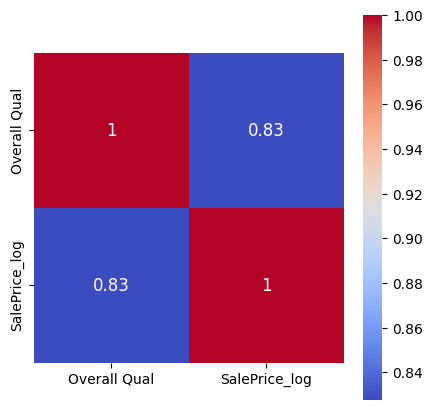

In [10]:
plt.figure(figsize=(5, 5)) 

sns.heatmap(
    data      = df_data[l_df_X_names_subset + ['SalePrice_log']].corr(),
    annot     = True,
    square    = True,
    annot_kws = {"size": 12},
    cmap      = 'coolwarm'
);

##### a3. Split the data

We split the subset of the data (`df_X_subset` and `ps_y_data_log`) using Scikit-Learn's `train_test_split()` ([*ref*](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html)).

In [11]:
# Split data in train and test sets.
df_X_train, df_X_test, ps_y_log_train, ps_y_log_test = train_test_split(
    
    df_X_subset,
    ps_y_data_log,
    test_size    = 0.3,
    random_state = 42
)

The function `f_train_test_split()` from the utils_pieter package does the same as Scikit-Learn's `train_test_split()` function, in addition, it prints some stats.

>**TIP** - Press CMD + / to toggle (un)commenting a section of code (Mac OS X). On Windows, this is CTRL + /.

In [12]:
#Split data in train and test sets.
df_X_train, df_X_test, ps_y_log_train, ps_y_log_test = f_train_test_split(
    
    df_X_subset,
    ps_y_data_log,
    n_test_size = 0.3
)

Dimension of df_X_train:                       2047 by 1
Dimension of df_X_test:                        878  by 1
Length of ps_y_train:                          2047
Length of ps_y_test:                           878

Combined number of rows in train and test set: 2925
Original number of rows:                       2925
Actual split:                                  0.3


##### a4. Scaling

The data in `df_X_subset` needs to be standardized so that each variable is represented and used at the same scale. Generally, there are two ways to scale variable data ([ref](https://www.analyticsvidhya.com/blog/2020/04/variable-scaling-machine-learning-normalization-standardization/)):

* Normalization is a scaling technique in which values are rescaled so that they end up ranging between 0 and 1. It is also known as Min-Max scaling.

* Standardization is another scaling technique where the values are centered around the mean with a unit standard deviation ([ref](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html)). This means that the mean of the variable becomes zero and the resulting distribution has a unit standard deviation.

There is no rule to tell you what to choose when. You can always start by fitting your model to normalized and standardized data, resp., and evaluate the two outcomes. In the example below, we will standardize the variable data so that each variable will have μ = 0 and σ = 1.

Scaling of the outcome variable is generally not required. Only when the outcome variable is not normally distributed - like in our case here - scaling will help to improve model performance.


##### To scale the data, we have two options:

1. Use scikit-learn's `fit_transform()` method.
1. Use scikit-learn's `fit()` and `transform()` methods separately.

The benefits of using fit_transform():

The fit_transform() method combines the actions of fit() and transform() into a single step. This one-line solution is convenient and improves the code’s readability and efficiency, whereas executing fit() and transform() separately requires two lines of code.

The downsides of using fit_transform() are threefold:

1.	**Applying before train/test split** - If fit_transform() is used before splitting the data into training and testing sets, it causes information from the test data to leak into the training process. This can lead to overly optimistic performance estimates because the model has inadvertently gained insights from the test data ([ref](https://towardsdatascience.com/what-and-why-behind-fit-transform-vs-transform-in-scikit-learn-78f915cf96fe)).
2.	**Applying after train/test split** - If fit_transform() is used after splitting the data, separate transformers are fitted to the training and testing sets. This results in different means and standard deviations for each set, causing inconsistencies and potentially degrading the model’s performance.
3.	**Handling new data (estimates)** - When encountering new data after the initial training phase, it’s essential to use the transformer that was fitted on the training data to ensure consistency. If a new transformer is fitted on the new estimates, it would use different means and standard deviations, leading to discrepancies in data scaling and potentially compromising model predictions. What would you do in case you want to make a prediction for a single data point? Therefore, the transformer derived from fitting the training data should be reused to transform any new incoming data.

**Best Practice** - To avoid these issues, use `fit()` and `transform()` separately, and follow these steps:
1. **Split the data first** - Begin by splitting your dataset into training and testing sets.
2. **Fit on training data only** - Apply the fit() method on the training data to learn the scaling parameters (such as mean and standard deviation). The `fit()` method in scikit-learn is used to train a transformer, such as a scaler or encoder, on the provided data. During the fitting process, the transformer learns the necessary parameters to perform the transformation. For example, the transformer of a standard scaler learns the mean and standard deviation of each feature in the dataset. It’s important to note that fit() does not alter the data itself; instead, it prepares the transformer to apply the transformation when transform() is called. Essentially, fit() teaches the transformer how to convert input data into a transformed output based on the learned parameters.
3. **Transform both training and testing data** - Use the same fitted transformer to apply the transform() method on both the training and testing data. This ensures that the scaling is consistent and based solely on the training data. The `transform()` method in scikit-learn applies a previously fitted transformer to new data. After using the fit() method to learn the necessary parameters (like mean and standard deviation for scaling), transform() utilizes these parameters to modify the input data accordingly. For example, in standardization, transform() scales the data by subtracting the learned mean and dividing by the learned standard deviation. This ensures that the new data is processed consistently based on the characteristics of the data the transformer was originally fitted on.
4. **Transform new data using the fitted transformer** - For any new estimates or incoming data, use the already fitted transformer to apply the transform() method. This maintains consistency in how data is scaled and prevents the introduction of bias or discrepancies.

In [13]:
# Define scaling object.
scaler = StandardScaler()
 
# Standardization of variables in training data.
scaler_fitted_on_X_train = scaler.fit(df_X_train)

# Let's observe some key properties of scaler object.
pd.DataFrame(
    {
        'name': l_df_X_names_subset,
        'mean': scaler_fitted_on_X_train.mean_,
        'std': scaler_fitted_on_X_train.scale_
    }
)

,name,mean,std
0,Overall Qual,6.0757,1.3893


With the `scaler` object - that was 'fitted' on the variables in the training data - in our hands, we apply the scaler to transform the variables in the training data and the variables in the test data. As mentioned above, this approach avoids any information leakage from the test data into the training data.

In [14]:
df_X_train_scaled = pd.DataFrame(
    scaler_fitted_on_X_train.transform(df_X_train),
    columns = l_df_X_names_subset
)

df_X_test_scaled  = pd.DataFrame(
    scaler_fitted_on_X_train.transform(df_X_test),
    columns = l_df_X_names_subset
)

To confirm the result, we plot the scaled data in the training and test data.

In [15]:
alt.Chart(df_X_train_scaled).mark_bar().encode(
    x = alt.X(alt.repeat("column"), type='quantitative'),
    y = "count()"
).properties(
    width  = 200,
    height = 200,
    title = "Standardized training data"
).repeat(
    column = l_df_X_names_subset,          
)

alt.RepeatChart(...)

In [16]:
alt.Chart(df_X_test_scaled).mark_bar().encode(
    x = alt.X(alt.repeat("column"), type='quantitative'),
    y = "count()"
).properties(
    width  = 200,
    height = 200,
    title = "Standardized test data"
).repeat(
    column = l_df_X_names_subset,          
)

alt.RepeatChart(...)

##### a5. Train the model

Having completed all preparations, we can train the linear regression model on the train data. It starts by defining `mo_lin_reg` as an 'empty' linear regression model object. See scikit-learn's [`LinearRegression()`](https://scikit-learn.org/1.6/modules/generated/sklearn.linear_model.LinearRegression.html) to learn what hyperparameters it supports. Though for this exercise, we will only use the default values (e.g., include intercept), so we just pass on nothing.

In [17]:
mo_lin_reg = LinearRegression()

What attributes are available in the 'empty' model? The default hyperparameter settings.

In [18]:
mo_lin_reg.__dict__

{'fit_intercept': True,
 'copy_X': True,
 'tol': 1e-06,
 'n_jobs': None,
 'positive': False}

We update the object `mo_lin_reg` by fitting the model on the train data (input/output).

In [19]:
mo_lin_reg.fit(df_X_train_scaled, ps_y_log_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


Again, we use `__dict__` to see what attributes are available in the `mo_lin_reg` object. Now, we observe the presence of the regression coefficient(s) (`coef_`) and the intercept (`intercept_`).

In [20]:
mo_lin_reg.__dict__

{'fit_intercept': True,
 'copy_X': True,
 'tol': 1e-06,
 'n_jobs': None,
 'positive': False,
 'feature_names_in_': array(['Overall Qual'], dtype=object),
 'n_features_in_': 1,
 'coef_': array([0.33300341]),
 'rank_': 1,
 'singular_': array([45.2437841]),
 'intercept_': np.float64(12.014443916372993)}

##### a6. Interpret the coefficients

We observe a general trend that the larger the correlation with `SalePrice_log` the larger the fitted coefficient. Of course, we need more than one variable to make this conclusion.

In [21]:
mo_lin_reg.coef_

array([0.33300341])

In [22]:
print(f"Intercept: {mo_lin_reg.intercept_:,.2f}\n")

print("Coefficients:")

pd.DataFrame({
    'variable': l_df_X_names_subset,    
    'coeff':   [round(x,3) for x in mo_lin_reg.coef_],
    'corr':    df_pd_corr_table.query('name in @l_df_X_names_subset')['corr']
})

Intercept: 12.01

Coefficients:


,variable,coeff,corr
5,Overall Qual,0.333,0.828


##### a7. Make predictions based on estimated model and test data

The fitted model - present in `mo_line_reg` - is used to make `SalePrice_log` predictions for the test data.

In [23]:
ps_y_log_pred = mo_lin_reg.predict(df_X_test_scaled)

##### a8. Evaluate estimated model based on test data

There are three primary metrics that can be used to evaluate regression models:

* **Mean Absolute Error (MAE):** The easiest to understand. Represents average error.

* **Mean Squared Error (MSE):** Similar to MAE but noise is exaggerated and larger errors result in higher “punishment”, as the error is squared. MSE is harder to interpret than MAE as it’s not in base units, however, it is generally more popular.

* **Root Mean Squared Error (RMSE):** Most popular metric, and being the square root of MSE - the RMSE is better interpretable as it has the same unit as the outcome variable (Y). This makes RMSE the recommended metric to interpret your linear regression model.

Since we evaluate these metrics more often, a function `f_evaluate_results()` has been defined, as part of the package 'utils_pieter'. This function also returns a scatter plot of the predicted vs actual values.

In [24]:
f_evaluate_results(
    ps_y_true = ps_y_log_test,
    ps_y_pred = ps_y_log_pred
)

Performance Metrics:
MAE:  0.168
MSE:  0.048
RMSE: 0.219


alt.LayerChart(...)

We observe that
1. Adding more variables reduces RMSE
2. Removing the 5 houses whose grand living areas exceeds 4000 sq ft reduces the RMSE by 0.003 to 0.13.

**Performance results using df_reduced (RMSE)**
* 0.222: 'Overall Qual'
* 0.189: 'Overall Qual', 'Gr Liv Area'
* 0.178: 'Overall Qual', 'Gr Liv Area', 'Garage Cars'
* 0.176: 'Overall Qual', 'Gr Liv Area', 'Garage Cars', 'Garage Area'
* 0.166: 'Overall Qual', 'Gr Liv Area', 'Garage Cars', 'Garage Area', 'Total Bsmt SF'

**Performance results using df_scoped (RMSE)**
* 0.219: 'Overall Qual'
* 0.181: 'Overall Qual', 'Gr Liv Area'
* 0.170: 'Overall Qual', 'Gr Liv Area', 'Garage Cars'
* 0.167: 'Overall Qual', 'Gr Liv Area', 'Garage Cars', 'Garage Area'
* 0.153: 'Overall Qual', 'Gr Liv Area', 'Garage Cars', 'Garage Area', 'Total Bsmt SF'

#### b. Estimate a LASSO model, see sklearn's [Lasso](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Lasso.html) and [LassoCV](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LassoCV.html)

LASSO (Least Absolute Shrinkage and Selection Operator) is a regression analysis method that performs both variable selection and regularization in order to enhance the prediction accuracy and interpretability of the resulting machine learning model ([ref](https://machinelearningmastery.com/lasso-regression-with-python/)). Recall that for regularized linear regression a cost function is added. In case of LASSO this is:

$$ J(\Theta) = MSE (\Theta) + \alpha\sum\limits_{i=1}^n \mid{\Theta_{i}}\mid$$

The larger the hyperparameter $\alpha$ - sometimes referred to as $\lambda$ - the larger the penalty for including model parameters, and the more model parameters ($\Theta$) will be set to zero, resulting in a model based on fewer model parameters.


##### b1. Recap our objects and define a few more

In addition to the numerical variables in the data (`df_X`) you may also want to include categorical data to predict the `SalePrice`. To give an example, earlier, we observed that `Neighborhood` correlated well with `SalePrice`. This can be done by so-called 'One-Hot Encoding' ([ref1](https://machinelearningmastery.com/why-one-hot-encode-data-in-machine-learning/), [ref2](https://towardsdatascience.com/categorical-encoding-using-label-encoding-and-one-hot-encoder-911ef77fb5bd)). In the example below we add the `Neighborhood` variable to the predictor data. One-hot encoding adds new variables to the data, one for each unique value in the categorical feature, entering a '1' for observations where it had the concerned value and a '0' where it has not.
`
You can see that we use the `fit_transform()` method. As in case of scaling, we could perform 'fit' and 'transform' separately. However, the disadvantages of using `fit_transform()` are not applicable here. So, we can benefit from the simplicity of using it.

In [25]:
# Define a one-hot encoder object.
ohe = OneHotEncoder()

# The fit_transform() function produces a 'sparse matrix' (sm_)
# object. To convert the data to a data frame we first need to 
# convert it to a 'matrix' (m_).
sm_neighborhoods = ohe.fit_transform(df_data[['Neighborhood_full']])
m_neighborhoods  = sm_neighborhoods.toarray()

# In addition to creating the 'sm_neighborhood' object, we have
# also updated the one-hot encoder object 'ohe' itself. Now, it
# holds the 'categories_' attribute. Since it is an array in a
# list we take the first element by appending '[0]'. Note,
# (1)   If we encode more than one categorical feature, the list
#       contains a array for each feature.
# (2    We convert the default floats to integers to save memory.
#       This is more for demo purposes, since our dataset is
#       relatively small already.
df_X_ohe = pd.DataFrame(
    data    = m_neighborhoods,
    columns = ohe.categories_[0]
).astype('int')

# As expected, the created data frame has as many variables
# as there are unique values in the 'Neighborhood' variable
# in df_data and the same number of observations as df_data has.
print(f"Unique neighborhoods: {ohe.categories_[0]}\n")

print(f"Length of the 'categories_' attribute:         {len(ohe.categories_[0])}")
print(f"Number of unique neighborhoods in df_data:     {len(df_data['Neighborhood_full'].unique())}\n")

print(f"Dimensions of created data frame ('df_X_ohe'): {df_X_ohe.shape}")

Unique neighborhoods: ['Bloomington Heights' 'Blueste' 'Briardale' 'Brookside' 'Clear Creek'
 'College Creek' 'Crawford' 'Edwards' 'Gilbert' 'Green Hills' 'Greens'
 'Iowa DOT and Rail Road' 'Landmark' 'Meadow Village' 'Mitchell'
 'North Ames' 'North West Ames' 'Northpark Villa' 'Northridge'
 'Northridge Heights' 'Old Town' 'Sawyer' 'Sawyer West' 'Somerset'
 'South and West of Iowa State University' 'Stone Brook' 'Timberland'
 'Veenker']

Length of the 'categories_' attribute:         28
Number of unique neighborhoods in df_data:     28

Dimensions of created data frame ('df_X_ohe'): (2925, 28)


Combine the two dataframes horizontally, so we set 'axis' to 1.

In [26]:
df_X_combined = pd.concat([df_X, df_X_ohe], axis = 1)

# Comms to the user. The created data frame 'df_X_combined' has as many observations,
# as both 'X' and 'X_ohe' have, and as many columns as the two have together. 
print("\nThe sum of the number of columns in df_X and df_X_ohe must equal that in df_X_combined:")
print(f"Number of variables in df_X:          {df_X.shape[1]}")
print(f"Number of variables in df_X_ohe:      {df_X_ohe.shape[1]}")
print(f"Number of variables in df_X_combined: {df_X_combined.shape[1]}")

print("\nThe number of rows must all be the same:")
print(f"Number of rows in df_X:               {df_X.shape[0]}")
print(f"Number of rows in df_X_ohe:           {df_X_ohe.shape[0]}")
print(f"Number of rows in df_X_combined:      {df_X_combined.shape[0]}")


The sum of the number of columns in df_X and df_X_ohe must equal that in df_X_combined:
Number of variables in df_X:          38
Number of variables in df_X_ohe:      28
Number of variables in df_X_combined: 66

The number of rows must all be the same:
Number of rows in df_X:               2925
Number of rows in df_X_ohe:           2925
Number of rows in df_X_combined:      2925


##### b2. Visualize predictors

We show a sample of the combined data frame to clarify how one-hot coding works and how the result was added to the numerical data. In which neighborhoods are the first five houses located?

In [27]:
df_X_combined.head(5)

,Order,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,BsmtFin SF 1,BsmtFin SF 2,Bsmt Unf SF,Total Bsmt SF,1st Flr SF,2nd Flr SF,Low Qual Fin SF,Gr Liv Area,Bsmt Full Bath,Bsmt Half Bath,Full Bath,Half Bath,Bedroom AbvGr,Kitchen AbvGr,TotRms AbvGrd,Fireplaces,Garage Yr Blt,Garage Cars,Garage Area,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,Bloomington Heights,Blueste,Briardale,Brookside,Clear Creek,College Creek,Crawford,Edwards,Gilbert,Green Hills,Greens,Iowa DOT and Rail Road,Landmark,Meadow Village,Mitchell,North Ames,North West Ames,Northpark Villa,Northridge,Northridge Heights,Old Town,Sawyer,Sawyer West,Somerset,South and West of Iowa State University,Stone Brook,Timberland,Veenker
0,1,526301100,20,141.0,31770,6,5,1960,1960,112.0,639.0,0.0,441.0,1080.0,1656,0,0,1656,1.0,0.0,1,0,3,1,7,2,1960.0,2.0,528.0,210,62,0,0,0,0,0,5,2010,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
1,2,526350040,20,80.0,11622,5,6,1961,1961,0.0,468.0,144.0,270.0,882.0,896,0,0,896,0.0,0.0,1,0,2,1,5,0,1961.0,1.0,730.0,140,0,0,0,120,0,0,6,2010,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
2,3,526351010,20,81.0,14267,6,6,1958,1958,108.0,923.0,0.0,406.0,1329.0,1329,0,0,1329,0.0,0.0,1,1,3,1,6,0,1958.0,1.0,312.0,393,36,0,0,0,0,12500,6,2010,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
3,4,526353030,20,93.0,11160,7,5,1968,1968,0.0,1065.0,0.0,1045.0,2110.0,2110,0,0,2110,1.0,0.0,2,1,3,1,8,2,1968.0,2.0,522.0,0,0,0,0,0,0,0,4,2010,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
4,5,527105010,60,74.0,13830,5,5,1997,1998,0.0,791.0,0.0,137.0,928.0,928,701,0,1629,0.0,0.0,2,1,3,1,6,1,1997.0,2.0,482.0,212,34,0,0,0,0,0,3,2010,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


##### b3. Split the data

We define two scenarios:

Scenario A - Only use the numerical variables (df_X), excluding the one-hot encoded `Neighborhood_full` variable.

Scenario B - Use the combined data (df_X_combined), including the one-hot encoded `Neighborhood_full` variable.

Depending on what scenario you want to follow, add/remove the hash tags.

In [28]:
# Scenario A.
df_X_train, df_X_test, ps_y_log_train, ps_y_log_test = f_train_test_split(
    df_X,
    ps_y_data_log,
    n_random_state = 123
)

# Scenario B.
# df_X_train, df_X_test, ps_y_log_train, ps_y_log_test = f_train_test_split(
#     df_X_combined,
#     ps_y_data_log,
#     n_random_state = 123
# )

Dimension of df_X_train:                       1959 by 38
Dimension of df_X_test:                        966  by 38
Length of ps_y_train:                          1959
Length of ps_y_test:                           966

Combined number of rows in train and test set: 2925
Original number of rows:                       2925
Actual split:                                  0.33


##### b4. Scaling

As before, we standardize `df_X_train` and `df_X_test` separately.

In [29]:
# Define scaling object.
scaler = StandardScaler()
 
# Standardization of variables in train data.
scaler_fitted_on_X_train = scaler.fit(df_X_train)

# Key properties of scaler object for first 5 variables in df_X_train.
pd.DataFrame({
    'name': df_X_train.columns,
    'mean': scaler_fitted_on_X_train.mean_,
    'sd': scaler_fitted_on_X_train.scale_
}).head(5)

,name,mean,sd
0,Order,1.4626e+03,8.5222e+02
1,PID,7.1332e+08,1.8856e+08
2,MS SubClass,5.7445e+01,4.3013e+01
3,Lot Frontage,6.8825e+01,2.0864e+01
4,Lot Area,1.0105e+04,8.3285e+03


In [30]:
df_X_train_scaled = pd.DataFrame(
    scaler_fitted_on_X_train.transform(df_X_train),
    columns = df_X_train.columns
)

df_X_test_scaled  = pd.DataFrame(
    scaler_fitted_on_X_train.transform(df_X_test),
    columns = df_X_test.columns
)

Let's have a look at the scaled data. In the one-hot encoded neighborhood variables we observe that the 0's and 1's have been replaced by a negative and a positive number, resp.

In [31]:
df_X_train_scaled.head(5)

,Order,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,BsmtFin SF 1,BsmtFin SF 2,Bsmt Unf SF,Total Bsmt SF,1st Flr SF,2nd Flr SF,Low Qual Fin SF,Gr Liv Area,Bsmt Full Bath,Bsmt Half Bath,Full Bath,Half Bath,Bedroom AbvGr,Kitchen AbvGr,TotRms AbvGrd,Fireplaces,Garage Yr Blt,Garage Cars,Garage Area,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold
0,0.3278,-0.9816,1.4543,-0.7585,-0.7424,0.6412,-0.4956,1.1328,1.0888,-0.1622,-0.9919,-0.2936,1.5757,0.4781,0.2434,-0.7767,-0.1006,-0.4987,-0.8247,-0.2443,0.7902,-0.7459,-1.0293,-0.2106,-0.2849,0.6127,1.1392,1.6261,0.8126,0.4134,-0.4778,-0.3493,-0.107,-0.2859,-0.0602,-0.1017,-0.0792,-0.5986
1,0.2351,-0.9860,0.5244,0.0563,0.0474,-0.7870,1.3243,-0.0120,0.9938,-0.1032,-0.2092,-0.2936,-1.2202,-1.5952,-1.5588,0.4857,-0.1006,-0.8073,-0.8247,3.8807,-1.0267,-0.7459,0.1724,-0.2106,-0.9258,-0.9301,-0.2727,-1.0120,-0.8634,-0.4741,-0.7144,-0.3493,-0.107,-0.2859,-0.0602,-0.1017,2.1222,-0.5986
2,-1.5003,1.0022,0.2919,-0.4230,-0.0606,1.3553,3.1442,-2.3342,0.8988,-0.5869,-0.9919,-0.2936,0.8331,-0.2895,-0.6233,0.7297,-0.1006,0.1393,-0.8247,-0.2443,0.7902,-0.7459,0.1724,-0.2106,0.3559,-0.9301,-1.8808,-1.0120,-0.8634,-0.3194,2.6570,3.4516,-0.107,-0.2859,-0.0602,-0.1017,-0.8130,1.6551
3,-1.5332,-0.9438,-0.8706,0.7752,0.0114,-0.7870,1.3243,-0.5680,0.8988,0.0265,-0.2743,1.8577,-0.3577,0.0756,-0.2111,-0.7767,-0.1006,-0.8550,1.0941,-0.2443,-1.0267,-0.7459,0.1724,-0.2106,-0.2849,-0.9301,0.4332,0.3070,0.0770,-0.7591,-0.7144,-0.3493,-0.107,-0.2859,-0.0602,-0.1017,-0.4461,1.6551
4,0.1284,1.0761,1.4543,-1.2857,-0.7229,0.6412,0.4143,0.4787,0.0916,1.4185,1.0107,-0.2936,-0.4029,0.5226,0.8856,-0.7767,-0.1006,0.0047,1.0941,-0.2443,0.7902,-0.7459,-1.0293,-0.2106,-0.2849,0.6127,0.3156,0.3070,0.1794,1.1950,-0.7144,-0.3493,-0.107,-0.2859,-0.0602,-0.1017,0.2877,0.1526


To explain why the 0's and 1's in the one-hot-encoded columns have been transformed to negative and positive numbers.

In [32]:
# We create a dummy list of 0's and 1's.
l_temp = [1]*3 + [0]*2

ic(l_temp)
print(f"\nAverage:            {np.mean(l_temp)}")
print(f"Standard deviation: {np.std(l_temp)}")

# We standardize these numbers.
(l_temp - np.mean(l_temp)) / np.std(l_temp)


Average:            0.6
Standard deviation: 0.48989794855663565


ic| l_temp: [1, 1, 1, 0, 0]


array([ 0.81649658,  0.81649658,  0.81649658, -1.22474487, -1.22474487])

##### b5. Train the model

Instead of using Scikit Learn's [`Lasso()`](https://scikit-learn.org/stable/modules/linear_model.html#lasso) function to build a single model, we use [`LassoCV()`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LassoCV.html) to build a series of LASSO models. By default `LassoCV()` tests 100 different values for $\alpha$ (`n_alphas` = 100 by default). Instead we provide a list of $\alpha$'s to `LassoCV()` fitting a model at each provided $\alpha$. We create a logarithmically spaced list of 100 $\alpha$'s between a minimum and a maximum value. This approach is useful in case you want to investigate a broad range of $\alpha$'s focussing on both small and large numbers.

**Example of creating a logarithmically spaced list of $\alpha$'s, 'l_alpha'**

Let's explain the approach with a simple example. Assume a list of 5 sequential negative numbers, say [-4, -3, -2, -1, 0]. We use this list to generate a second list where each number from the first list is used as the exponent of a power with base 10. This results in the following list: [0.0001, 0.001, 0.01, 0.1, 1]. If we would have linearly spaced a range between 0 and 1, we would have ended up with [0, 0.25, 0.5, 0.75, 1]. By, logarithmically spacing the list, we can quickly investigate how big or small $\alpha$ needs to be. Of course, we can create a list with lots of numbers using a small step size, but this will take a long time to evaluate.


In [33]:
# Minimum and maximum value of the list ('l_alpha') and the number of elements in said list.
n_alpha_min = 0.0001
n_alpha_max = 0.05
n_alpha     = 100

# Log of lower and upper alpha and step size of log scale.
n_alpha_min_log  = np.log10(n_alpha_min)
n_alpha_max_log  = np.log10(n_alpha_max)
n_alpha_step_log = (n_alpha_max_log - n_alpha_min_log) / n_alpha

# List of log of alphas.
l_alpha_log = np.arange(
    n_alpha_min_log,
    n_alpha_max_log + n_alpha_step_log,
    n_alpha_step_log
)

# List of alphas.
l_alpha = [

    # Calculation of alpha.
    round(10**i, 5)

    # Loop through list of log of alphas (i.e., exponents).
    for i in l_alpha_log
]

# First and last elements.
print(f"{l_alpha[:3]} ... {l_alpha[-3:]}")

[np.float64(0.0001), np.float64(0.00011), np.float64(0.00011)] ... [np.float64(0.04416), np.float64(0.04699), np.float64(0.05)]


In [34]:
# Define LassoCV model.
mo_lasso = LassoCV(
    
    cv           = 5,       # Number of folds.
    random_state = 42,      # Fixing random_state ensures the results are reproducible.
    max_iter     = 1000,    # Max number of iterations.
    alphas       = l_alpha  # We enforce for which alphas a Lasso model is fitted.
                            # In case we do not provide a list, LassoCV() will select 100 values.
).fit(   
    df_X_train_scaled,
    ps_y_log_train
)

##### b6. Interpret the coefficients

For each alpha and each fold we calculate the RMSE on the training data. For each alpha we calculate the average RMSE across the five folds.

In [35]:
#pd.set_option("display.precision", 3)

df_lasso = (
    
    pd.DataFrame(np.sqrt(mo_lasso.mse_path_))
    .rename(columns   = {i : f"rmse_{i+1}" for i in range(5)})
    .assign(rmse_mean = np.sqrt(mo_lasso.mse_path_.mean(axis=1)))
    .assign(alpha     = mo_lasso.alphas_)
    .sort_values(by = 'alpha')
    .reset_index(drop = True)
)

# Transform the data frame to long format.
df_lasso_long = pd.melt(
    df_lasso,
    id_vars    = 'alpha',
    var_name   = 'fold',
    value_name = 'rmse'
)

df_lasso.head(15)

,rmse_1,rmse_2,rmse_3,rmse_4,rmse_5,rmse_mean,alpha
0,0.1472,0.1228,0.1078,0.1474,0.1190,0.1298,0.0001
1,0.1472,0.1228,0.1078,0.1474,0.1191,0.1298,0.0001
2,0.1472,0.1228,0.1078,0.1474,0.1191,0.1298,0.0001
3,0.1472,0.1228,0.1078,0.1475,0.1191,0.1298,0.0001
4,0.1472,0.1228,0.1078,0.1475,0.1191,0.1298,0.0001
5,0.1472,0.1228,0.1078,0.1475,0.1191,0.1298,0.0001
6,0.1472,0.1228,0.1077,0.1475,0.1191,0.1298,0.0001
7,0.1472,0.1228,0.1077,0.1475,0.1191,0.1298,0.0001
8,0.1472,0.1227,0.1077,0.1475,0.1191,0.1298,0.0002
9,0.1472,0.1227,0.1077,0.1475,0.1191,0.1298,0.0002


The best model is selected based on the lowest average RMSE. The $\alpha$ for that model can be obtained through the attribute `alpha_`. We can confirm the numbers from 'df_lasso' above

In [36]:
print(
    f"We observe the lowest RMSE {min(df_lasso.rmse_mean):.4f} "
    f"at alpha: {mo_lasso.alpha_:,.4f}"
)

We observe the lowest RMSE 0.1297 at alpha: 0.0009


For each of the five folds we plot the RMSE against the respective $\alpha$'s we added as parameter to `LassoCV()`, see red solid lines in the figure below. We also add the average of the five folds, see black line. This plot allows us to choose the optimal $\alpha$, i.e., the one that results in the lowest RMSE, see dotted vertical line. What can we conclude from the black line?

In [37]:
base_chart = alt.Chart(df_lasso_long).mark_line().encode(
    x     = alt.X('alpha', scale = alt.Scale(type='log'), title="Alpha"),
    y     = alt.Y('rmse',  scale = alt.Scale(domain=[0.1, 0.25])),
    color = alt.Color(
        'fold',
        scale = alt.Scale(
            domain = [f"rmse_{i+1}" for i in range(5)] + ['rmse_mean'],
            range  = ['red']*5 + ['black']
        )
    )
)

# Add a vertical dotted line at alpha = mo_lasso.alpha_
vertical_dotted_line = alt.Chart(df_lasso_long).mark_rule(
        color      = 'red',
        strokeDash = [5,5]
    ).encode(
        x = alt.X('a:Q', title="")
    ).transform_calculate(
        a = str(mo_lasso.alpha_)
    )

# Combine the scatter plot and the vertical dotted line
base_chart + vertical_dotted_line

alt.LayerChart(...)

From the `mo_lasso` object we can extract the intercept and coefficients of the best model, see table below:

What explains the number of coefficients equal to zero?

How can we increase the number of coefficients equal to zero?

Explain the position of 'Garage Cars' and 'Garage Area'.

In [38]:
print(f"intercept: {mo_lasso.intercept_:,.2f}")

df_lasso_coefficients = (
    
    pd.DataFrame({
        'name':            df_X_train_scaled.columns,
        'lasso coeff':     mo_lasso.coef_,
        'lasso_coeff_abs': abs(mo_lasso.coef_)        
    }).sort_values(
        'lasso_coeff_abs',
        ascending=False
    )
)

df_lasso_coefficients

intercept: 12.02


,name,lasso coeff,lasso_coeff_abs
17,Gr Liv Area,1.3444e-01,1.3444e-01
5,Overall Qual,1.1486e-01,1.1486e-01
7,Year Built,9.6038e-02,9.6038e-02
6,Overall Cond,5.8751e-02,5.8751e-02
13,Total Bsmt SF,4.3628e-02,4.3628e-02
10,BsmtFin SF 1,3.5241e-02,3.5241e-02
27,Garage Cars,2.7325e-02,2.7325e-02
4,Lot Area,1.9995e-02,1.9995e-02
25,Fireplaces,1.9686e-02,1.9686e-02
8,Year Remod/Add,1.8026e-02,1.8026e-02


##### b7. Make predictions based on estimated model and test data

The `mo_lasso` object holds the properties of the best model, i.e., the one resulting in the lowest RMSE.

In [39]:
ps_y_log_pred = mo_lasso.predict(df_X_test_scaled)

##### b8. Evaluate estimated model based on test data

The same three primary metrics are used to evaluate the best LASSO model. The RMSE is considerably lower than with the linear regression model, however, we require a lot more variables. Using $\alpha$ we can reduce the number of included variables, but this goes at the 'expense' of a higher RMSE.

In [40]:
f_evaluate_results(
    ps_y_true = ps_y_log_test,
    ps_y_pred = ps_y_log_pred
)

Performance Metrics:
MAE:  0.087
MSE:  0.017
RMSE: 0.131


alt.LayerChart(...)

**Linear Regression**

**Performance results using df_reduced (RMSE)**
* 0.222: 'Overall Qual'
* 0.189: 'Overall Qual', 'Gr Liv Area'
* 0.178: 'Overall Qual', 'Gr Liv Area', 'Garage Cars'
* 0.176: 'Overall Qual', 'Gr Liv Area', 'Garage Cars', 'Garage Area'
* 0.166: 'Overall Qual', 'Gr Liv Area', 'Garage Cars', 'Garage Area', 'Total Bsmt SF'

**Performance results using df_scoped (RMSE)**
* 0.219: 'Overall Qual'
* 0.181: 'Overall Qual', 'Gr Liv Area'
* 0.170: 'Overall Qual', 'Gr Liv Area', 'Garage Cars'
* 0.167: 'Overall Qual', 'Gr Liv Area', 'Garage Cars', 'Garage Area'
* 0.153: 'Overall Qual', 'Gr Liv Area', 'Garage Cars', 'Garage Area', 'Total Bsmt SF'

**Lasso**

We observe that the test error is slightly higher in case of the scoped data (0.131) than in case of the reduced data (0.129). The training error is lower in case of the scoped data (0.130) than in case of the reduced data (0.165). 

Regularization techniques, such as Lasso, restrict a model’s complexity by limiting the magnitude of its parameters. This prevents overfitting—where the model fits the training data too closely—but can result in slightly higher training error since the model doesn’t capture every nuance and noise in the data. However, by maintaining simpler patterns, the model generalizes better to unseen data, often achieving improved performance on test sets. In essence, regularization trades some training accuracy to enhance the model’s reliability on new, diverse datasets.

**Performance results using df_reduced (RMSE)**
* Scenario A: 0.129 (training error = 0.165)
* Scenario B: 0.121 (training error = 0.154)

**Performance results using df_scoped (RMSE)**
* Scenario A: 0.131 (training error = 0.130)
* Scenario B: 0.125 (training error = 0.123)

#### c. Estimate a kNN model, see scikit-learn's [k Nearest Neighbors Regressor](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsRegressor.html#sklearn.neighbors.KNeighborsRegressor)

In addition, we develop a kNN model to predict the `SalePrice_log` ([ref1](https://realpython.com/knn-python/), [ref2](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsRegressor.html#sklearn.neighbors.KNeighborsRegressor)). We define a KNeighborsRegressor object, called `mo_knn`, that is further informed by fitting the training data. Contrary to (LASSO) regression, we keep this section on kNN simple and to the point; you got the idea.

In [41]:
# Define KNN object.
mo_knn = KNeighborsRegressor(n_neighbors = 2)

mo_knn.fit(df_X_train_scaled, ps_y_log_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",2
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


The trained kNN model is used to predict `SalePrice` for the train and test data. We do this to investigate overfitting.

In [42]:
f_evaluate_results(
    ps_y_true = ps_y_log_train,
    ps_y_pred = mo_knn.predict(df_X_train_scaled)
)

Performance Metrics:
MAE:  0.074
MSE:  0.011
RMSE: 0.107


alt.LayerChart(...)

In [43]:
f_evaluate_results(
    ps_y_true = ps_y_log_test,
    ps_y_pred = mo_knn.predict(df_X_test_scaled)
)

Performance Metrics:
MAE:  0.122
MSE:  0.030
RMSE: 0.174


alt.LayerChart(...)

For low values of `n_neighbors` the model is highly flexible and we are running the risk of over-fitting. Observing the RMSE value for the train and test set, we can conclude that we are indeed overfitting. We can make use of SciKit Learn's `GridSearchCV()` function to work through a series of hyperparameters, and determine for which hyperparameter we found the best model. Of the possible hyperparameters, see [k-Nearest Neighbors Regressor](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsRegressor.html#sklearn.neighbors.KNeighborsRegressor), we can consider `n_neighbors`, i.e., the number of neighbors.

In [44]:
parameters = {"n_neighbors": range(1, 50)}
gridsearch = GridSearchCV(KNeighborsRegressor(), parameters)

gridsearch.fit(df_X_train_scaled, ps_y_log_train)

# Comms to the user
print(f"We found the best model for {gridsearch.best_params_}.")

We found the best model for {'n_neighbors': 10}.


In [45]:
f_evaluate_results(
    ps_y_true = ps_y_log_train,
    ps_y_pred = gridsearch.predict(df_X_train_scaled)
)

Performance Metrics:
MAE:  0.105
MSE:  0.023
RMSE: 0.152


alt.LayerChart(...)

In [46]:
f_evaluate_results(
    ps_y_true = ps_y_log_test,
    ps_y_pred = gridsearch.predict(df_X_test_scaled)
)

Performance Metrics:
MAE:  0.111
MSE:  0.027
RMSE: 0.163


alt.LayerChart(...)

Indeed, no over-fitting.

**Linear Regression**

**Performance results using df_reduced (RMSE)**
* 0.222: 'Overall Qual'
* 0.189: 'Overall Qual', 'Gr Liv Area'
* 0.178: 'Overall Qual', 'Gr Liv Area', 'Garage Cars'
* 0.176: 'Overall Qual', 'Gr Liv Area', 'Garage Cars', 'Garage Area'
* 0.166: 'Overall Qual', 'Gr Liv Area', 'Garage Cars', 'Garage Area', 'Total Bsmt SF'

**Performance results using df_scoped (RMSE)**
* 0.219: 'Overall Qual'
* 0.181: 'Overall Qual', 'Gr Liv Area'
* 0.170: 'Overall Qual', 'Gr Liv Area', 'Garage Cars'
* 0.167: 'Overall Qual', 'Gr Liv Area', 'Garage Cars', 'Garage Area'
* 0.153: 'Overall Qual', 'Gr Liv Area', 'Garage Cars', 'Garage Area', 'Total Bsmt SF'

**Lasso**

**Performance results using df_reduced (RMSE)**
* Scenario A: 0.129 (training error = 0.165)
* Scenario B: 0.121 (training error = 0.154)

**Performance results using df_scoped (RMSE)**
* Scenario A: 0.131 (training error = 0.130)
* Scenario B: 0.125 (training error = 0.123)

**kNN**

We observe that the training error decreases when adding the neighborhood data and when moving from reduced to scoped data. In three of the four cases, the test error is somewhat higher than the training data, as expected.

**Performance results using df_reduced (RMSE)**
* Scenario A: 0.152 (training error = 0.162 / n_neighbors = 11)
* Scenario B: 0.160 (training error = 0.151 / n_neighbors = 5)

**Performance results using df_scoped (RMSE)**
* Scenario A: 0.163 (training error = 0.152 / n_neighbors = 10)
* Scenario B: 0.173 (training error = 0.145 / n_neighbors = 5)



## Exercise 6 - Assess which model performs best

### Evaluation

This is discussed with each of the models. I leave making the overall assessment to you.

In [ ]:
# Create dictionary 'dc_exercise_5_6' with objects that will be used in ML Explainers.
dc_exercise_5_6 = {
    'df_lasso_coefficients':    df_lasso_coefficients,
    'df_X_train_scaled':        df_X_train_scaled,
    'ps_y_log_train':           ps_y_log_train
}

# Save dc_exercise_5_6 as 'dc-ames-housing-pieter-exercise-5-6.pkl'
with open('data/dc-ames-housing-pieter-exercise-5-6.pkl', 'wb') as pickle_file:
    pickle.dump(dc_exercise_5_6, pickle_file)